In [1]:

from macd_functions import *    # stock functions , not used for MFs


from mftool import Mftool
mf = Mftool()

from functools import reduce

### Part 1 is for General MF analysis. 
- It can be for all MFs or Portfolio MFs read from a file
- This doesnt have amount invested info
- Funds are catagorised like below:
    - small, mid, large, hybrid
    - flexi (multi, thematic ...)
    - hedge (multi asset, debt, overseas, gold, ... (having low or negative corralation with market))


### Part 2 is for studying portfolio with Amount info added

In [4]:


### To get specific MF codes for portfolio funds, refer 'mf_ga_amfi.csv' and follow below steps


### Visit --> mf._const['get_quote_url'] --> https://www.amfiindia.com/spages/NAVAll.txt

## OR
## == to get via coding and filtering, 
result = mf.get_scheme_codes()      
# get_available_schemes('canara')
# mf.get_scheme_historical_nav(120828,as_Dataframe=True)



In [10]:
mf_names = [
    "Aditya Birla Sun Life Equity Hybrid'95 Fund Growth Direct", "Aditya Birla Sun Life Equity Hybrid '95 Fund Growth Regular", "Aditya Birla Sun Life Equity Savings Fund Direct Plan", "Aditya Birla Sun Life Regular Savings Fund Growth Direct Plan", "Canara Robeco Consumer Trends Fund Regular Plan", "Canara Robeco Flexi Cap Fund Regular Plan", "Canara Robeco Gilt Fund Direct Growth", "Canara Robeco Large Cap Fund Direct Growth", "HDFC Balanced Advantage Fund Regular", "HDFC Hybrid Equity Fund Regular Plan Growth", "HDFC Flexi Cap Fund Direct Plan Growth", "HDFC Hybrid Equity Fund Regular Plan Growth", "HDFC NIFTY 200 Momentum 30 INDEX FUND Direct Growth", "Kotak Aggressive Hybrid Fund Direct Plan Growth", "Kotak Balanced Advantage Fund Direct Growth", "Kotak Debt Hybrid Fund Direct Plan Growth", "Kotak Midcap Fund Direct Plan Growth", "Mahindra Manulife Mid Cap Fund Regular Growth", "Mirae Asset INDIA SMALL CAP FUND Regular Plan GROWTH", "PGIM India Flexi Cap Fund Direct", "PGIM India Midcap Fund Direct Plan Growth", "Union Flexi cap fund growth direct", "Union Liquid Fund Growth Direct Plan"
]

In [14]:
[(k,v) for name in mf_names for k,v in result.items() if all(a.lower() in v.lower() for a in name.split())]

[('120517',
  "Aditya Birla Sun Life Equity Hybrid'95 Fund - Direct Plan-Growth"),
 ('103155',
  "Aditya Birla Sun Life Equity Hybrid'95 Fund - Regular Plan-Growth"),
 ('132995',
  'Aditya Birla Sun Life Equity Savings Fund - Direct Plan - Growth'),
 ('120705',
  'Aditya Birla Sun Life Regular Savings Fund - Growth / Payment - Direct Plan'),
 ('112152',
  'CANARA ROBECO CONSUMER TRENDS FUND - REGULAR PLAN - GROWTH OPTION'),
 ('112153',
  'CANARA ROBECO CONSUMER TRENDS FUND - REGULAR PLAN - IDCW (Payout/Reinvestment)'),
 ('101922', 'CANARA ROBECO FLEXICAP FUND - REGULAR PLAN - GROWTH OPTION'),
 ('101923',
  'CANARA ROBECO FLEXICAP FUND - REGULAR PLAN - IDCW (Payout/Reinvestment)'),
 ('118299', 'CANARA ROBECO GILT FUND - DIRECT PLAN - GROWTH OPTION'),
 ('118278',
  'CANARA ROBECO LARGE AND MID CAP FUND - DIRECT PLAN - GROWTH OPTION'),
 ('118269', 'CANARA ROBECO LARGE CAP FUND - DIRECT PLAN - GROWTH OPTION'),
 ('118955', 'HDFC Flexi Cap Fund - Growth Option - Direct Plan'),
 ('133035', 'K

## Part 1 -- MF Analysis

In [2]:
period = '5y'    ## period for MF analysis .. longer the better ... '1y', '3y'

num_years = int(period[0])
count = 252 * num_years      # 252 for 1 year


## Reference for Risk Free return --> # kotak liquid fund
risk_free_mf = '0P0000XV6E.BO'   
risk_free_hist = yf.Ticker(risk_free_mf).history(period=period)
risk_free_hist['Week'] = risk_free_hist.index.strftime('%Y-%U')
risk_free_hist['Month'] = risk_free_hist.index.strftime('%Y-%m')
risk_free_hist['DATE'] = risk_free_hist.index.strftime('%Y-%m-%d')


## Reference for Market Benchmark return --> # Nifty50
market = '^NSEI'
market_hist = yf.Ticker(market).history(period=period)
market_hist['Week'] = market_hist.index.strftime('%Y-%U')
market_hist['Month'] = market_hist.index.strftime('%Y-%m')
market_hist['DATE'] = market_hist.index.strftime('%Y-%m-%d')


## Merging Risk free and Market returns datewise; --> to be used for MF ratio calculation
riskfree_market_df = pd.merge(risk_free_hist[['DATE', 'Close']], market_hist[['DATE', 'Close']],
                              suffixes=('_risk', '_market'),
                              on='DATE', how='inner')

ratio_names = ['beta', 'sharpe', 'alpha', 'info', 'up_capture', 'down_capture']

def get_ratios(hist_df, mf_cat):
    '''
    hist_df: daily returns of a stock/MF
    '''
    hist_df['Month'] = hist_df.index.strftime('%Y-%m')
    hist_df['Week'] = hist_df.index.strftime('%Y-%U')
    hist_df['DATE'] = hist_df.index.strftime('%Y-%m-%d')

    hist_riskfree_market_df = pd.merge(riskfree_market_df, hist_df[['DATE', 'Week', 'Close']], on='DATE', how='inner')

    ## Daily Returns in %
    returns_df = hist_riskfree_market_df.groupby('DATE')[['Close_risk','Close_market','Close']].mean().pct_change().dropna()   # Week, DATE
    returns_df.rename(columns={'Close_risk':'risk_free_return', 'Close_market':'market_return', 'Close':'weekly_return'}, inplace=True)

    
    ## ==== RATIOS ====
    # beta -- Covariance with Market/variance (self-covariance) of market
    covariance = np.cov(returns_df['weekly_return'], returns_df['market_return'])
    beta = covariance[0,1] / covariance[1,1]   


    # Alpha -- Return beyond market return
    expected_return = returns_df['risk_free_return'] + beta * (returns_df['market_return'] - returns_df['risk_free_return'])
    alpha = returns_df['weekly_return'] - expected_return
    
    
    # Sharpe
    excess_return = returns_df['weekly_return'] - returns_df['risk_free_return']
    num_period = returns_df.shape[0]
    # -- to be averaged on yearly basis. 52 if weekly and 252 (working days) if daily returns
    # -- scale factor for yearly ratio -- np.sqrt(252) or np.sqrt(52) 
    #       --> Stats stuff: Annual number is directly proportional to mean and variance (sqrt for std)
    sharpe_ratio = np.sqrt(252) * excess_return.mean() / excess_return.std()
    

    # Information Ratio -- Return over benchmark
    excess_return = returns_df['weekly_return'] - returns_df['market_return']
    info_ratio = np.sqrt(252) * excess_return.mean() / excess_return.std()
    
    
    ####################
    
    ## Capture Ratio
    mf_cat = mf_cat if mf_cat in benchmark_idx['id'] else 'large_3'
    
    hist_benchmark_df = pd.merge(benchmark_df[['date', mf_cat+'_Close']].rename(columns={'date':'DATE'}),
                                   hist_df, on='DATE', how='inner')
    # Month-on-Month Returns in %
    hist_benchmark_df.index = pd.to_datetime(hist_benchmark_df['DATE'], format="%Y-%m-%d")
    returns_df = hist_benchmark_df.resample('ME').last()[[mf_cat+'_Close','Close']].pct_change().dropna()
    
    # Upside and Downside
    up_fund_ret, up_benchmark_ret = returns_df[returns_df[mf_cat+'_Close'] >= 0][['Close', mf_cat+'_Close']].T.values
    down_fund_ret, down_benchmark_ret = returns_df[returns_df[mf_cat+'_Close'] < 0][['Close', mf_cat+'_Close']].T.values
    # Calculate the cumulative product (1 + return_1) * (1 + return_2) * ... - 1
    up_fund_ret_cumu = (1 + up_fund_ret).prod() - 1
    up_benchmark_ret_cumu = (1 + up_benchmark_ret).prod() - 1
    down_fund_ret_cumu = (1 + down_fund_ret).prod() - 1
    down_benchmark_ret_cumu = (1 + down_benchmark_ret).prod() - 1
    #
    upside_capture_ratio = (up_fund_ret_cumu / up_benchmark_ret_cumu) * 100
    downside_capture_ratio = (down_fund_ret_cumu / down_benchmark_ret_cumu) * 100
    overall_capture_ratio = upside_capture_ratio / downside_capture_ratio



    return {'sharpe':round(sharpe_ratio,2),
            'beta':round(beta,2),
            'alpha':round(alpha.mean()*100,2),
            'info':round(info_ratio,2),
            'up_capture':upside_capture_ratio,
            'down_capture':downside_capture_ratio
            }


###===================



## Get rolling ratios == to study the evolution over time : More consistent the better
roll_lengths = [18]   # [12,15,18,24] months

def rolling_results(hist_df, mf_cat):
    hist_df['Month'] = hist_df.index.strftime('%Y-%m')
    months = hist_df['Month'].unique()
    roll_result_df = pd.DataFrame(columns=['start_month','roll_length']+ratio_names)
    roll_elas = {}
    for roll_len in roll_lengths:
        roll_sets = [months[i:i+roll_len] for i in range(len(months)-roll_len+1)]
        for roll_months in roll_sets:
            roll_df = hist_df[hist_df['Month'].isin(roll_months)].copy()
            vals = get_ratios(roll_df, mf_cat)

            roll_result_df.loc[len(roll_result_df)] = [roll_df['Month'].iloc[0], roll_len] + list(vals.values())

    return roll_result_df.to_dict(orient='list')


###====================

# Benchmark Ref for Info ratio
benchmark_idx = {'name':['large', 'mid', 'small', 'flexi'],    # nippon, MO ,nippon, MO
                 'id':['large_3', 'mid_2', 'small_1', 'flexi_4'],
                 'code':[118741, 147622, 148519, 147625],
                 }
# 'balanced':'CRISIL Hybrid 50+50 - Moderate Index',
# 'debt':'CRISIL Hybrid 85+15 - Conservative Index'

benchmark_df = []
for idx, code in zip(benchmark_idx['id'], benchmark_idx['code']):
    df = mf.get_scheme_historical_nav(code,as_Dataframe=True).iloc[::-1].iloc[-count:].astype(float)
    df.rename(columns={'nav':idx+'_Close'}, inplace=True)
    df.index = pd.to_datetime(df.index, format="%d-%m-%Y").strftime('%Y-%m-%d')
    benchmark_df.append(df.reset_index()[['date', idx+'_Close']])
benchmark_df = reduce(lambda left, right: pd.merge(left, right, on='date', how='outer'), benchmark_df)


###=================


## List of all MFs available in the market
names = ['small_1', 'mid_2', 'large_3', 'flexi_4']
idx = 1    # Index of category to be studied
mf_dict = mf.get_available_schemes(names[idx].split('_')[0])

## Extract single fund for each house-category from the entire list
mf_dict_ref = {k:v for k,v in mf_dict.items() if all(w in v.lower() for w in ['direct','growth'])}
if names[idx]=='mid_2': mf_dict_ref = {k:v for k,v in mf_dict_ref.items() if 'large' not in v.lower() and 'small' not in v.lower()}
if names[idx]=='large_3': mf_dict_ref = {k:v for k,v in mf_dict_ref.items() if 'mid' not in v.lower()}


mf_all = {'name':list(mf_dict_ref.values()),
          'id':names[idx],
          'code':list(mf_dict_ref.keys()),
          }


In [7]:





df['Month'] = df.index.strftime('%Y-%m')
months = df['Month'].unique()
print(months)
num_years = 1
rolling_returns = []
for roll_len in [12]:
    roll_sets = [months[i:i+roll_len] for i in range(len(months)-roll_len+1)]
    for roll_months in roll_sets:
        roll_df = df[df['Month'].isin(roll_months)].copy()
        cagr = (roll_df['Close'].iloc[-1] / roll_df['Close'].iloc[0]) ** (1 / num_years) - 1
        rolling_returns.append(cagr * 100)


['2021-03' '2021-04' '2021-05' '2021-06' '2021-07' '2021-08' '2021-09'
 '2021-10' '2021-11' '2021-12' '2022-01' '2022-02' '2022-03' '2022-04'
 '2022-05' '2022-06' '2022-07' '2022-08' '2022-09' '2022-10' '2022-11'
 '2022-12' '2023-01' '2023-02' '2023-03' '2023-04' '2023-05' '2023-06'
 '2023-07' '2023-08' '2023-09' '2023-10' '2023-11' '2023-12' '2024-01'
 '2024-02' '2024-03' '2024-04' '2024-05' '2024-06' '2024-07' '2024-08'
 '2024-09' '2024-10' '2024-11' '2024-12' '2025-01' '2025-02' '2025-03'
 '2025-04' '2025-05' '2025-06' '2025-07' '2025-08' '2025-09' '2025-10'
 '2025-11' '2025-12' '2026-01' '2026-02' '2026-03' '2026-04']


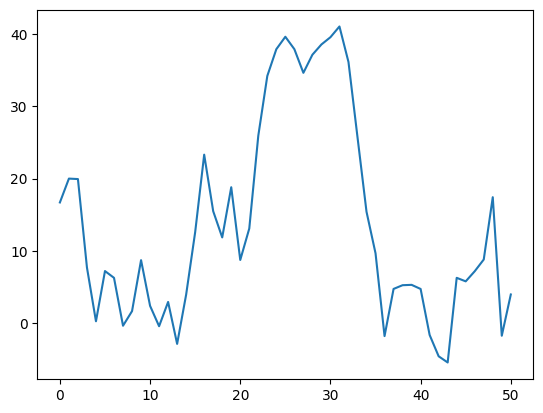

In [11]:
plt.plot(rolling_returns)

In [12]:
np.mean(rolling_returns), np.std(rolling_returns), np.median(rolling_returns)

(np.float64(13.825653912773378),
 np.float64(13.907641093079336),
 np.float64(8.724608536502698))

In [3]:

# Flag to analyse All MFs or Portfolio MFs
all_MFs = False 


## Read portfolio MFs stored in csv
mf_df = pd.read_csv('mf_ga_amfi.csv')
    
if not all_MFs:
    # Appending benchmark for each category for comparison
    mf_df = pd.concat([mf_df, pd.DataFrame.from_dict(benchmark_idx)])
else:
    # my_codes = mf_df['code'].to_list()
    my_mf_names = mf_df[mf_df['id']==names[idx]]['name'].apply(lambda x: ' '.join(x.split(' ')[:2])).str.lower().tolist()
    ## All MFs
    mf_df = pd.DataFrame.from_dict(mf_all)
    ## Get MFs which are in Portfolio
    mf_df['short_name'] = mf_df['name'].apply(lambda x: ' '.join(x.split(' ')[:2])).str.lower()
    my_codes = mf_df[mf_df['short_name'].isin(my_mf_names)]['code'].to_list()
    mf_df['portfolio'] = mf_df['code'].apply(lambda x: 1 if x in my_codes else 0)
    my_mf_names = mf_df[mf_df['portfolio'] == 1]['name'].values


mf_fall = {}
latest = []


ratios = {k: [] for k in ratio_names}
rolling_ratios = {k: [] for k in ratio_names}

mf_names = mf_df['name'].values
returns_report = {}
rolling_returns = {}

##== Iterate for each MF separately 
for idx, row in mf_df.iterrows():
    
    df = mf.get_scheme_historical_nav(row['code'],as_Dataframe=True)
    df.rename(columns={'nav':'Close'}, inplace=True)
    df = df.iloc[::-1]
    df['Close'] = df['Close'].astype(float)
    df = df.iloc[-count:]    # Consider from last given years
    df.index = pd.to_datetime(df.index, format="%d-%m-%Y")

    # Latest NAV
    latest.append(df.iloc[0]['Close'])

    ## After 26th Sept 2024 -- High before started falling
    if df[df.index <= '2024-09-26'].shape[0]:
        mf_fall[row['name']] = df['Close'].loc[df[df.index == '2024-09-26'].index[0]:].values
    else:
        mf_fall[row['name']] = df['Close'].values


    # Ratios
    vals = get_ratios(df.copy(), row['id'])
    for k in ratios:
        ratios[k].append(vals[k])

    # Rolling ratios
    roll_vals = rolling_results(df.copy(), row['id'])
    for k in rolling_ratios:
        rolling_ratios[k].append(roll_vals[k])

    # Report returns
    if df.shape[0] == count:
        cagr = (df['Close'].iloc[-1] / df['Close'].iloc[0]) ** (1 / num_years) - 1
        returns_report[row['name']] = cagr * 100
    else:
        returns_report[row['name']] = np.nan


## Summariese into a DF
for k in ratios:
    mf_df[k] = ratios[k]
mf_df['nav'] = latest

for k in rolling_ratios:
    mf_df[f'rolling_{k}'] = rolling_ratios[k]

mf_df['returns_%'] = mf_df['name'].map(returns_report)

# mf_df.sort_values(['id', 'info'], ascending=False)
mf_df.round(2)

,name,id,code,beta,sharpe,alpha,info,up_capture,down_capture,nav,rolling_beta,rolling_sharpe,rolling_alpha,rolling_info,rolling_up_capture,rolling_down_capture,returns_%
0,HDFC Balanced Advantage Fund - Direct Plan - G...,hybrid_5,118968,0.63,1.13,0.03,0.89,87.32,55.18,251.89,"[1.66, 1.41, 1.61, 1.33, 1.16, 0.94, 0.84, 0.5...","[0.59, 0.59, 0.59, 0.6, 0.6, 0.6, 0.6, 0.6, 0....","[0.05, 0.04, 0.04, 0.04, 0.04, 0.03, 0.04, 0.0...","[0.72, 0.82, 0.76, 0.58, 0.73, 0.77, 1.41, 1.3...","[84.01019921498157, 84.01019921498157, 77.3190...","[26.727481083676324, 30.778521485622022, 30.77...",17.28
1,HDFC Flexi Cap Fund - Direct Plan - Growth Option,flexi_4,118955,0.88,1.07,0.04,1.78,102.48,72.46,861.00,"[1.4, 1.19, 1.39, 1.16, 0.98, 0.8, 0.62, 0.39,...","[0.91, 0.9, 0.9, 0.91, 0.91, 0.91, 0.91, 0.91,...","[0.05, 0.04, 0.05, 0.04, 0.04, 0.04, 0.05, 0.0...","[1.51, 1.57, 1.63, 1.35, 1.44, 1.41, 2.08, 1.8...","[104.96210930939552, 106.47297813017983, 105.6...","[57.029028085506916, 61.47359851645693, 61.473...",19.94
2,HDFC Hybrid Debt Fund - Direct Plan - Growth O...,hybrid_5,119118,0.24,0.85,0.01,-0.19,30.98,20.58,55.83,"[1.24, 1.44, 1.14, 1.32, 1.11, 0.8, 0.49, 0.26...","[0.22, 0.22, 0.22, 0.23, 0.23, 0.23, 0.23, 0.2...","[0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.0, 0.01...","[-0.42, -0.5, -0.3, -0.47, -0.41, -0.27, -0.15...","[35.93400061644725, 36.72199673132436, 36.7219...","[13.381246752382795, 13.381246752382795, 18.89...",9.55
3,HDFC Index FundNIFTY 50 Plan - Direct Plan,large_3,119063,1.00,0.43,0.00,3.46,99.90,100.12,136.84,"[0.84, 0.6, 0.78, 0.68, 0.47, 0.3, -0.1, -0.21...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0.01, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[4.16, 3.98, 4.0, 3.99, 3.58, 3.21, 3.28, 3.2,...","[99.89137953027961, 99.89137953027961, 99.8544...","[100.03411116050766, 99.98439040686905, 99.984...",11.26
4,HDFC NIFTY Next50 Index Fund Direct Growth,large_3,149288,1.08,0.37,0.02,0.52,170.24,123.00,9.99,"[-0.47, -0.18, -0.1, 0.09, 0.17, -0.04, -0.16,...","[0.98, 0.97, 0.97, 0.96, 0.94, 0.95, 0.97, 0.9...","[-0.02, -0.02, -0.01, -0.01, -0.01, -0.0, -0.0...","[-0.58, -0.45, -0.34, -0.19, -0.26, -0.12, -0....","[96.92826993251475, 112.90389419367463, 113.17...","[138.64032871196275, 138.64032871196275, 130.2...",NaN
5,ICICI Prudential Balanced Advantage Fund - Dir...,hybrid_5,120377,0.41,0.93,0.01,0.07,45.06,30.95,48.07,"[1.46, 1.26, 1.41, 1.17, 0.96, 0.7, 0.41, 0.22...","[0.34, 0.34, 0.34, 0.34, 0.34, 0.34, 0.34, 0.3...","[0.02, 0.02, 0.02, 0.01, 0.01, 0.01, 0.01, 0.0...","[-0.35, -0.11, -0.3, -0.28, -0.11, 0.01, 0.45,...","[43.31454537247452, 43.31454537247452, 42.7620...","[9.882956826400825, 14.367807262211851, 14.367...",12.02
6,ICICI Prudential Focused Equity Fund - Direct ...,flexi_4,120722,0.91,0.96,0.03,1.64,118.31,88.57,42.98,"[1.13, 0.92, 1.11, 0.94, 0.69, 0.45, 0.12, -0....","[0.89, 0.9, 0.9, 0.9, 0.9, 0.89, 0.88, 0.88, 0...","[0.02, 0.03, 0.03, 0.02, 0.02, 0.01, 0.02, 0.0...","[0.99, 1.12, 1.1, 0.91, 0.79, 0.61, 0.97, 0.84...","[107.14953554959581, 106.98825803335244, 109.8...","[90.93085754950916, 89.50858523461423, 89.5085...",19.42
7,ICICI Prudential Multi-Asset Fund - Direct Pla...,hedge_6,120334,0.55,1.48,0.04,1.02,79.44,28.50,362.00,"[1.84, 1.64, 1.81, 1.65, 1.56, 1.33, 1.05, 0.7...","[0.55, 0.55, 0.54, 0.54, 0.54, 0.54, 0.53, 0.5...","[0.05, 0.05, 0.05, 0.05, 0.05, 0.04, 0.05, 0.0...","[0.76, 0.93, 0.79, 0.77, 1.02, 1.03, 1.4, 1.28...","[83.02615715069214, 83.02615715069214, 78.6334...","[0.3345749328106946, 15.95736604387365, 15.957...",19.58
8,ICICI Prudential Nifty50 Value20 Index Fund - ...,large_3,152365,0.93,-0.29,-0.01,-0.48,76.02,96.80,9.99,"[-0.15, -0.28, -0.22, -0.09, -0.12, -0.29, -0....","[0.96, 0.96, 0.96, 0.96, 0.97, 0.97, 0.96, 0.9...","[-0.02, -0.02, -0.01, -0.02, -0.02, -0.01, -0....","[-0.96, -0.78, -0.67, -0.83, -0.82, -0.63, -0....","[79.02842573432822, 86.05124686790333, 80.9459...","[117.3352747307507, 110.3013360002903, 110.301...",NaN
9,ICICI Prudential Smallcap 

### Result Analysis

### 1. Percentage Change compared to All Time High
- MFs having returns >0 shows good recovery compared to Market and other peers
- Mfs are color coded in Plot for segregation
- 'mid', 'small', 'large', 'flexi' --> show market benchmark returns compared to ATH

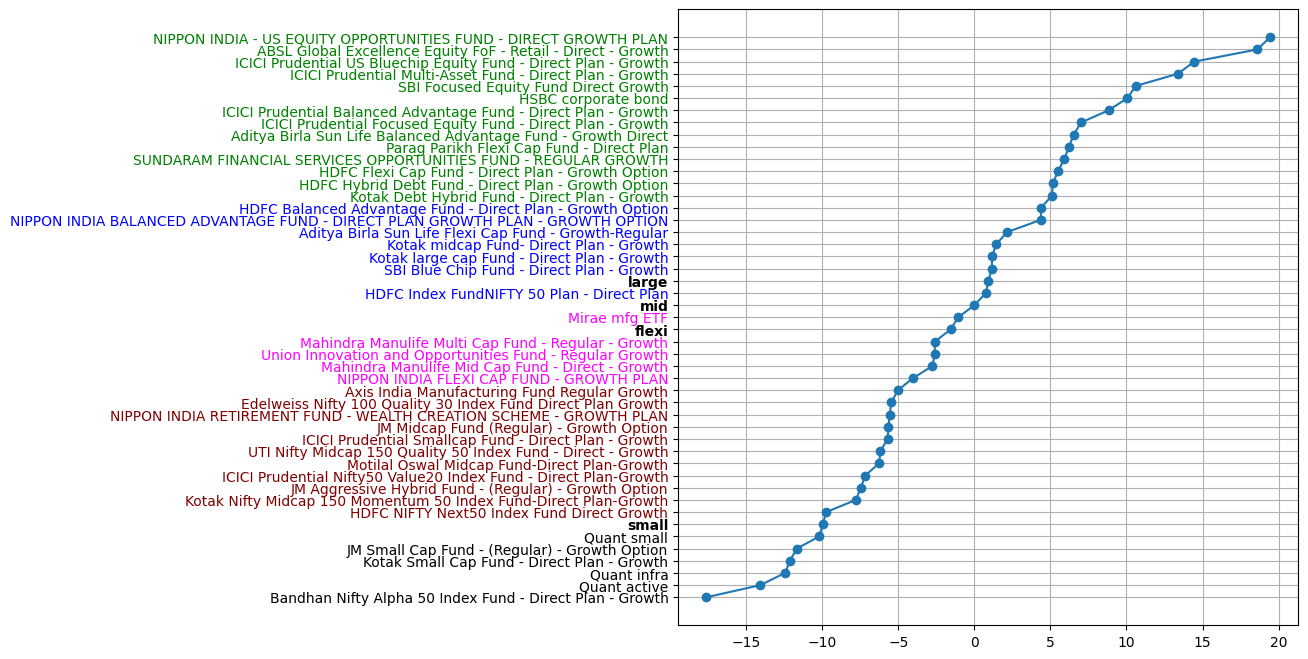

In [12]:
## Percentage variation

fig = plt.figure(figsize=(8,8))

change_list, mf_names = [], []
for name, vals in mf_fall.items():
    change = (vals[-1] - vals[0])/vals[0]
    change_list.append(round(change*100, 2))
    mf_names.append(name)

mf_names1, change_list = zip(*sorted(zip(mf_names, change_list), key=lambda x: x[1]))

plt.plot(change_list, mf_names1, marker='o')

ax = plt.gca()
for i, label in enumerate(ax.get_yticklabels()):
    if change_list[i] > 5: label.set_color('green')
    elif change_list[i] < 5 and change_list[i] > 0: label.set_color('blue')
    elif change_list[i] < 0 and change_list[i] > -5: label.set_color('magenta')
    elif change_list[i] < -5 and change_list[i] > -10: label.set_color('maroon')
    if label.get_text() in benchmark_idx['name']:
        label.set_fontweight('bold')
        label.set_color('black')
    # Highlight my MFs
    if all_MFs:
        if label.get_text() in my_mf_names: label.set_fontweight('bold')


plt.grid(True, which='both')
plt.show()

### 2.1 Absolute returns for all_mfs
- Useful to check missed out value compared to other funds

In [7]:
if all_MFs:
    beginning_value = 1000000
    mf_df['abs_return'] = beginning_value * (1 + mf_df['returns_%'])**num_years

    df_plot = mf_df[['name', 'id', 'code', 'returns_%', 'abs_return']].sort_values('returns_%', ascending=True)
    plt.plot(df_plot['returns_%'], df_plot['name'], marker='o')
    plt.xlabel(f'Absolute Returns of {beginning_value} over {num_years} years')
    plt.grid()

    ax = plt.gca()
    for i, label in enumerate(ax.get_yticklabels()):
        # Highlight my MFs
        if label.get_text() in my_mf_names: label.set_fontweight('bold')


### 2. Category-wise Percentage Variation from ATH for detailed analysis
- To analyse performance/behaviour of MF over last year

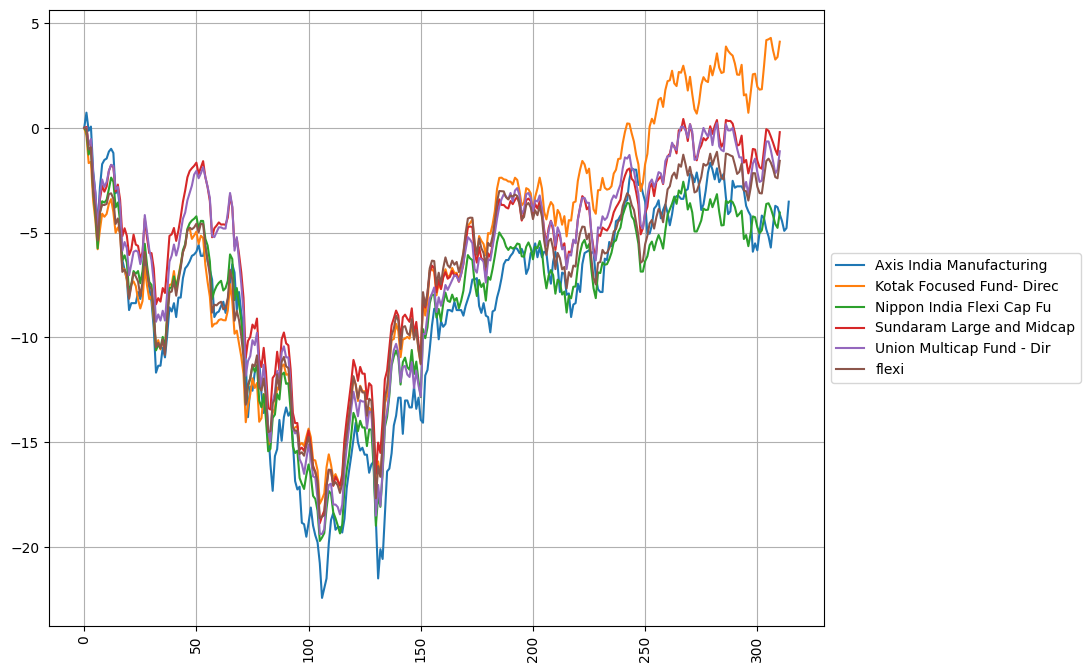

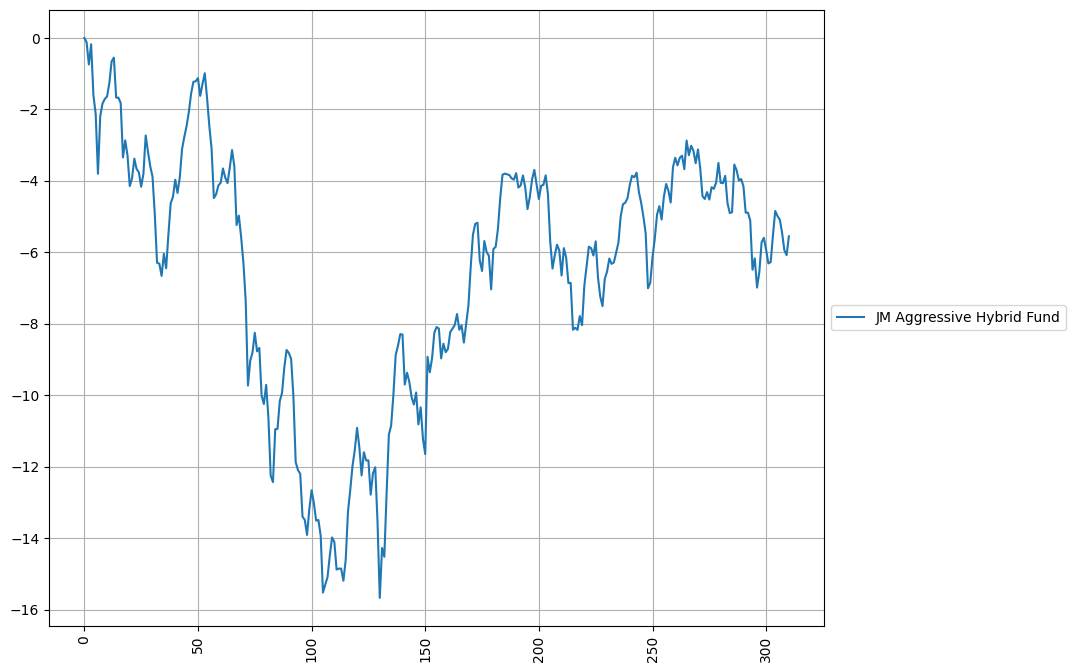

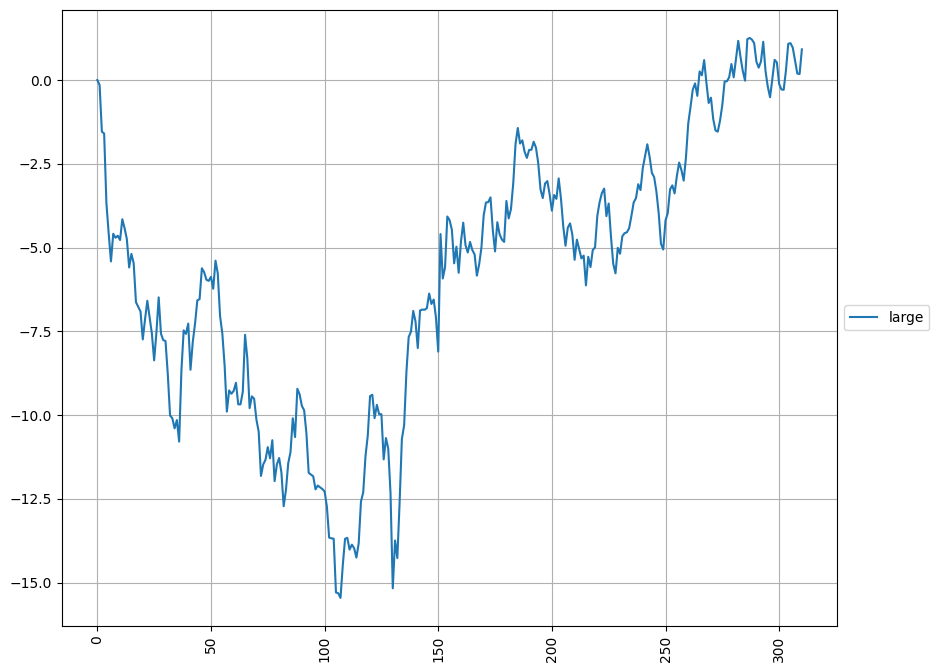

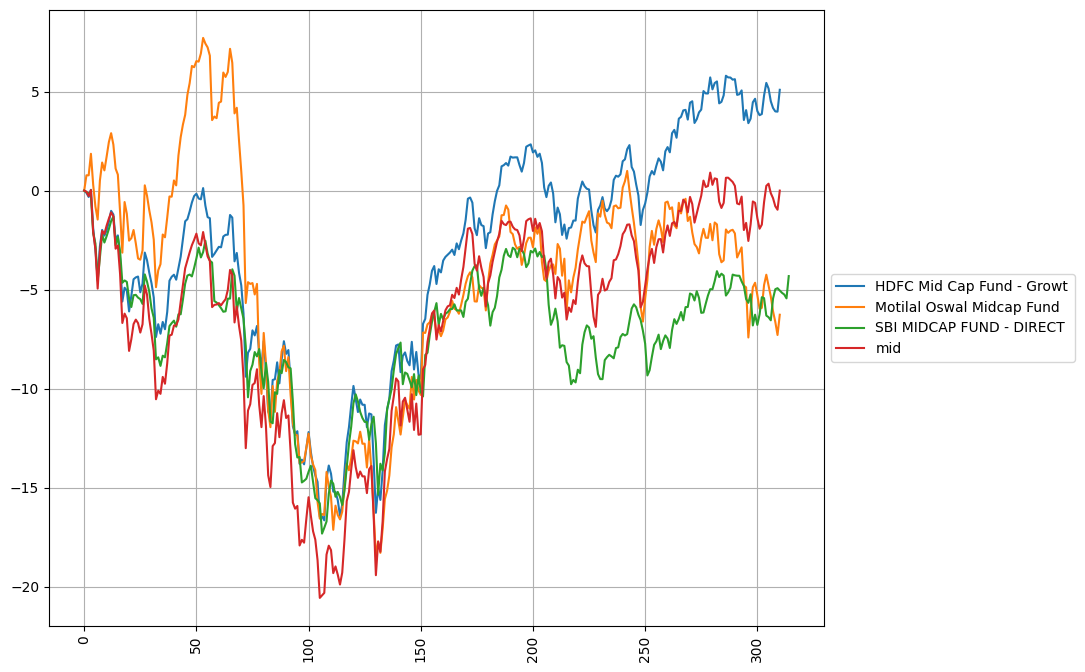

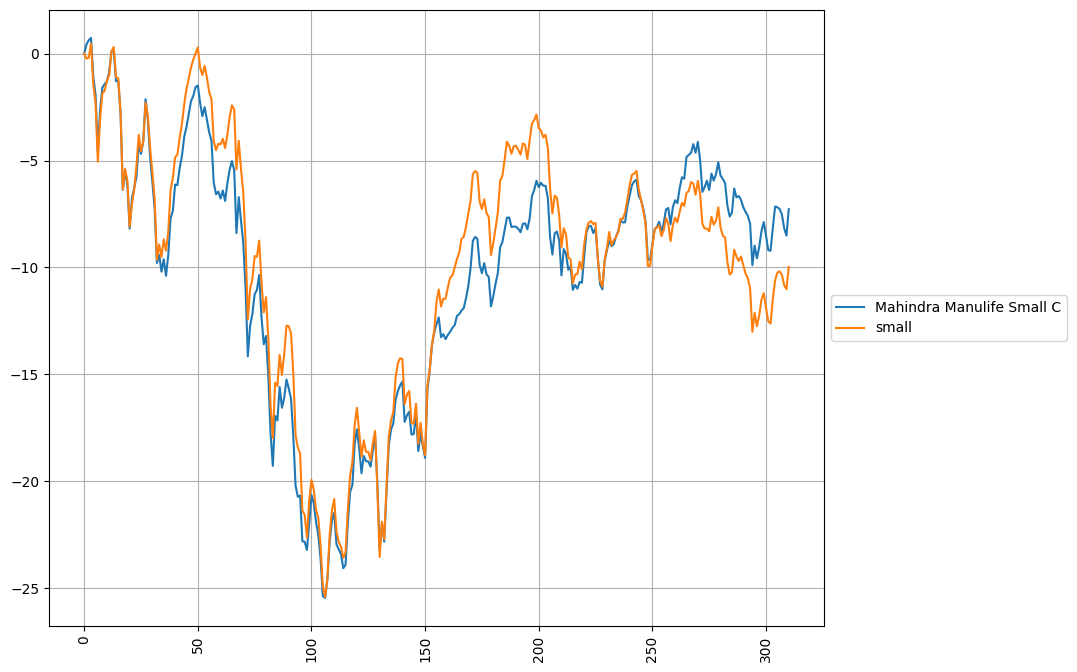

In [8]:

for cat, df in mf_df.groupby('id'):
    fig = plt.figure(figsize=(10,8))

    for idx, row in df.iterrows():
        vals = mf_fall[row['name']]
        pc_var = (vals - vals[0])*100/vals[0]
        plt.plot(pc_var, label=row['name'][:25])
    plt.xticks(rotation=90)
    plt.grid(True, which='both')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.show()




### 3. Analysis of Ratios -- Important

1. Sharpe Ratio: Returns over risk free, weighted by its variance. Higher value is better returns comapred to Risk taken
    - Neagtive sharpe ratio: Underperformance of asset in a given period.
    
2. Beta: Relative volatality with Market.
    - Low value means less fluctuations compared to market and Good for short term durations
    
3. Alpha: Extra return over Market and Risk free return, weighted by Beta
4. Info: it measures ability to generate risk-adjusted excess returns above a benchmark, quantifying a fund manager's skill and consistency in outperforming the market.
    - Its fund's return over benchmark return, divided by SD of this excess return.
    - Higher value shows that fund manager is consistently generating higher returns than the benchmark with less risk.
    - Sharpe is with Risk free and Info with benchmark
    
    - (There is intentional bug in code. Info Ratio is calculated with Nifty50 for general comparision. Ideally its calculated with category benchmark for that fund (eg. mid, small, flexi)
    
5. Capture Ratio
    - Upside Ratio > 100%: The fund outperforms the benchmark during rising markets.
    - Downside Ratio < 100%: The fund loses less than the benchmark during falling markets, indicating better risk mitigation.
    - Overall Ratio > 1: The fund has provided superior risk-adjusted returns overall compared to its benchmark. 

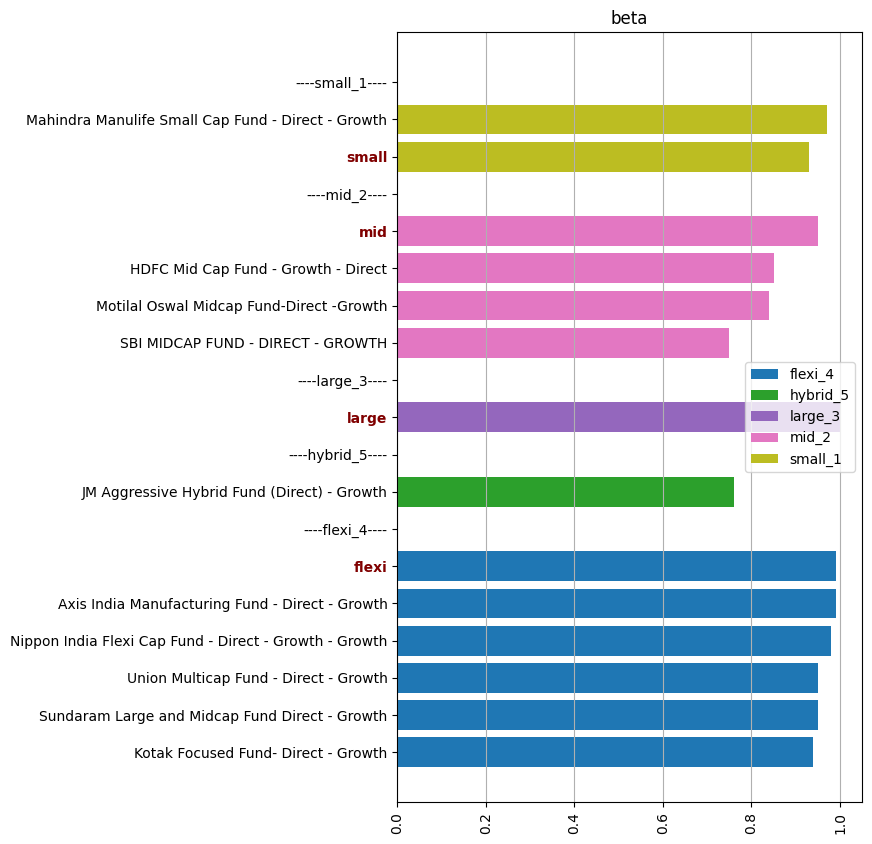

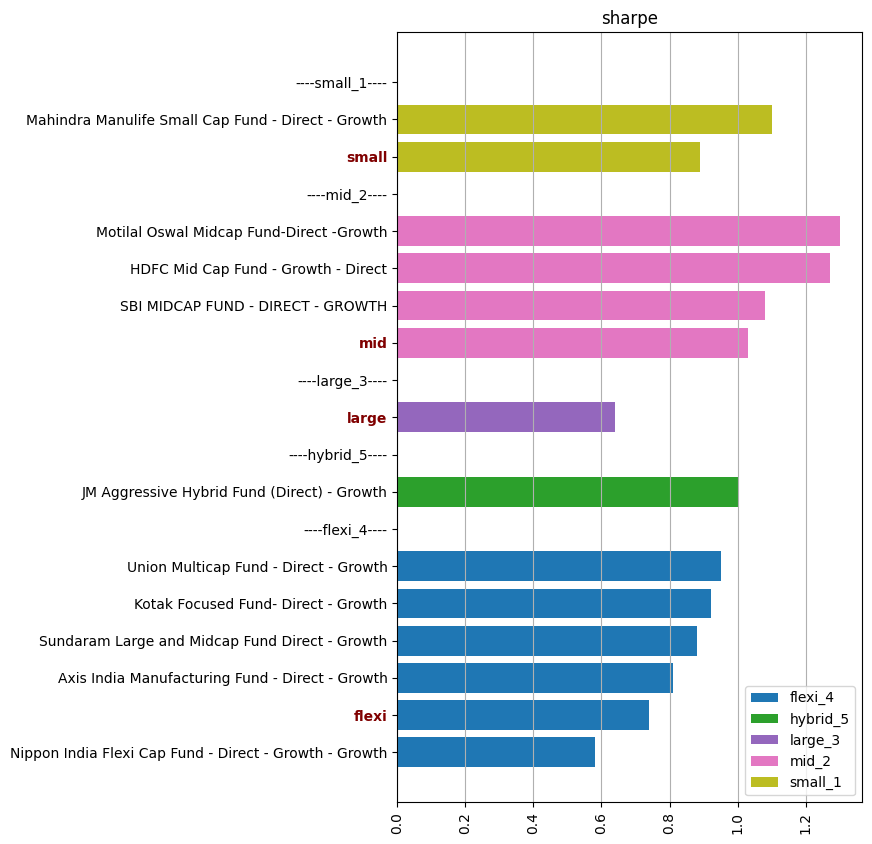

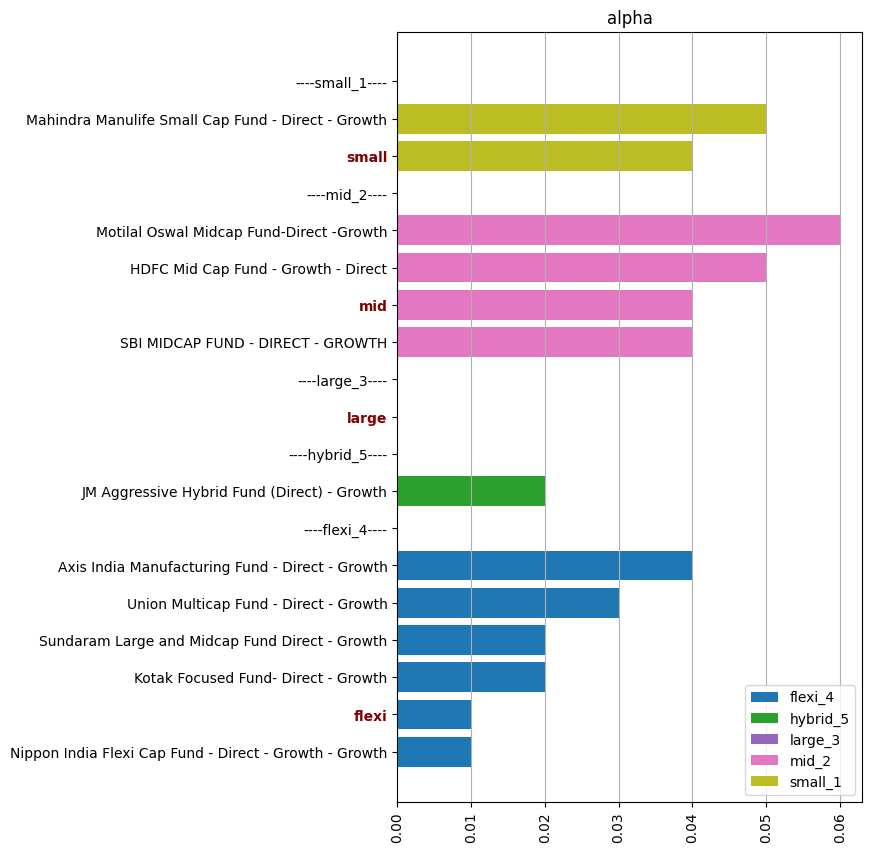

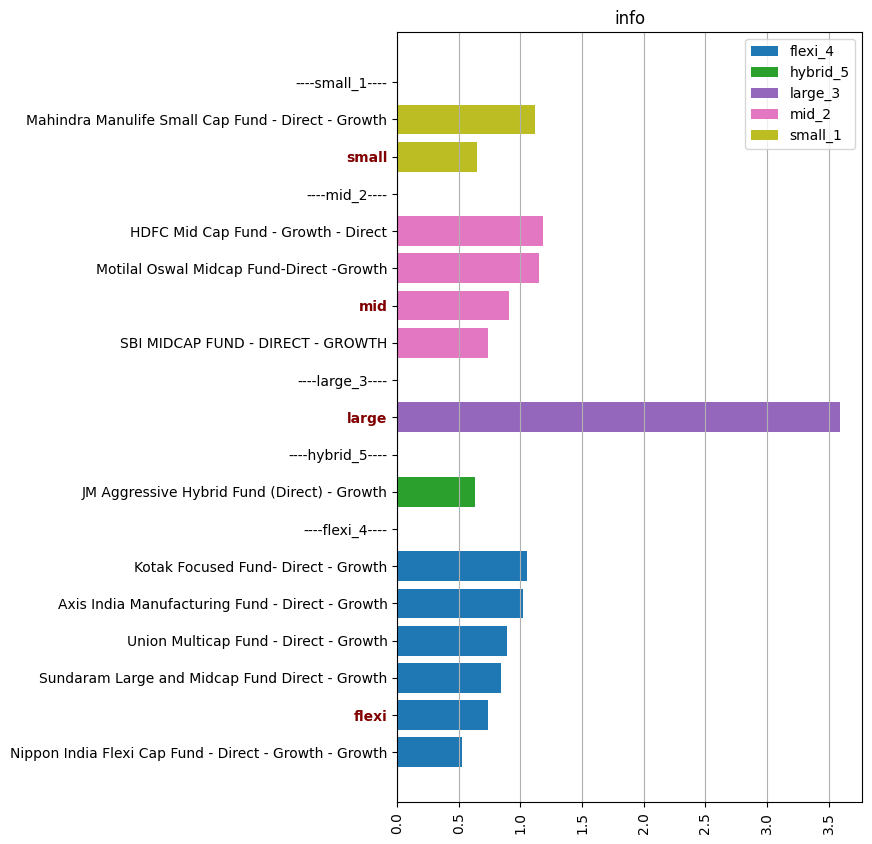

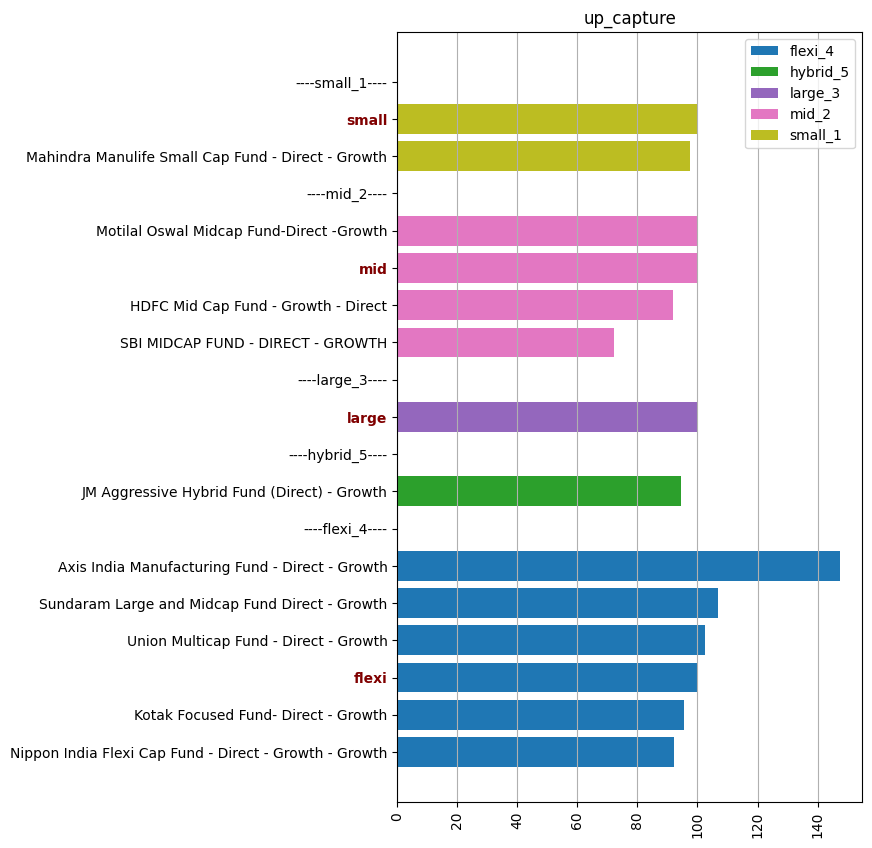

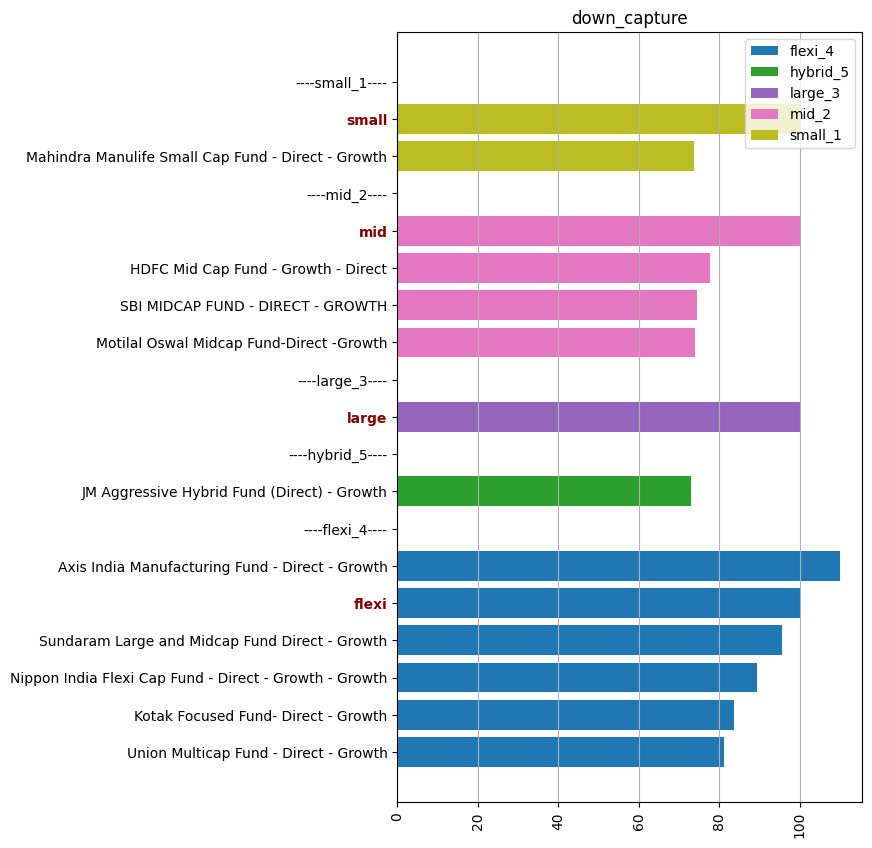

In [9]:

for ratio in ratios.keys():
    fig = plt.figure(figsize=(6,10))
    for cat, df in mf_df.groupby('id'):
        df = df.sort_values(by=ratio)
        plt.barh(df['name'], df[ratio], label=cat)
        plt.barh('----'+cat+'----', 0, label=None)
    plt.title(ratio)
    plt.xticks(rotation=90)
    plt.grid(True, axis='x')
    plt.legend()

    ax = plt.gca()
    for i, label in enumerate(ax.get_yticklabels()):
        if label.get_text() in benchmark_idx['name']:
            label.set_fontweight('bold')
            label.set_color('maroon')

        # Highlight my MFs
        if all_MFs:
            if label.get_text() in my_mf_names: label.set_fontweight('bold')

    plt.show()



### 3.1 Returns vs Ratios for MFs

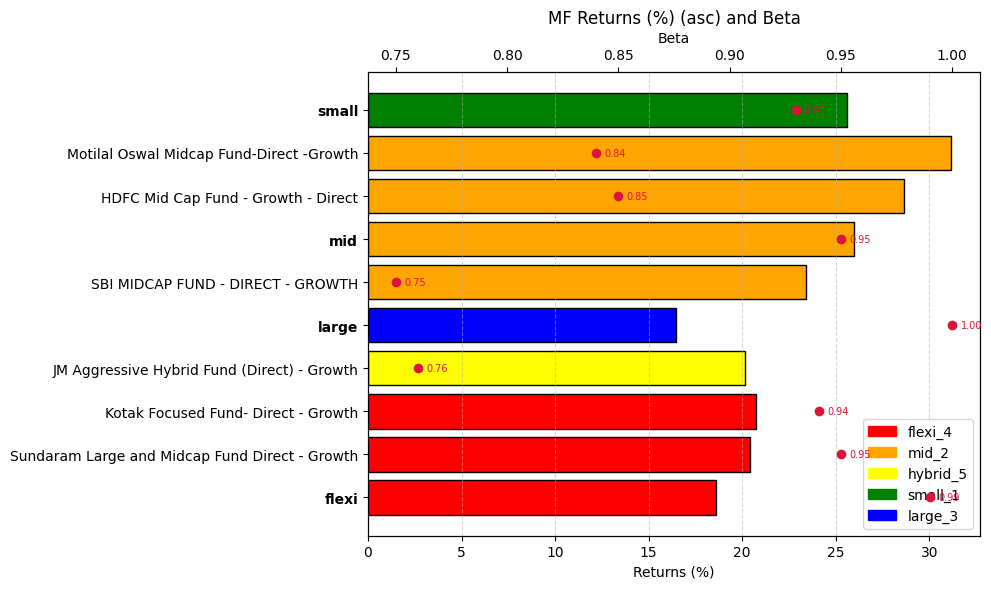

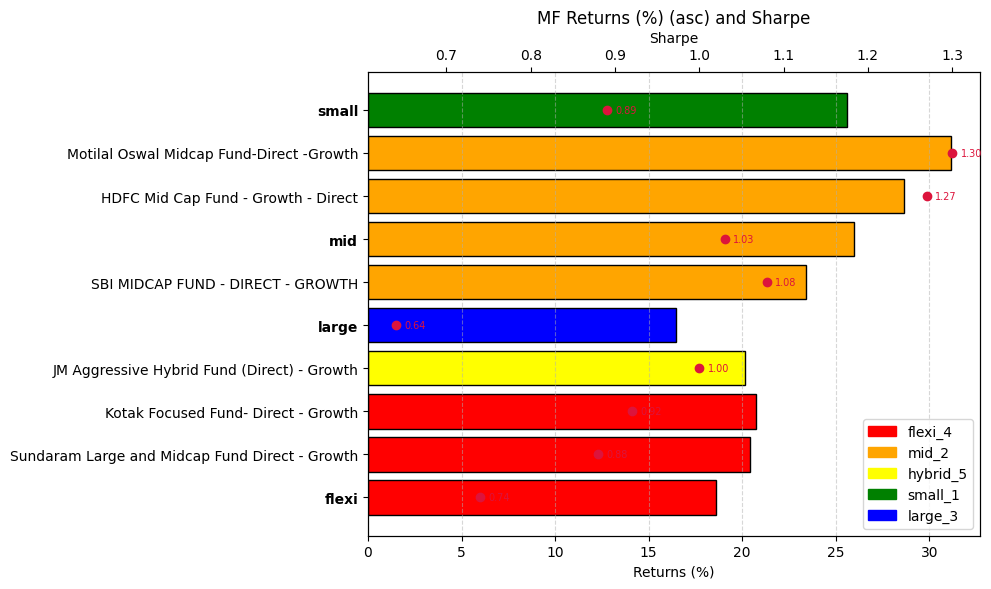

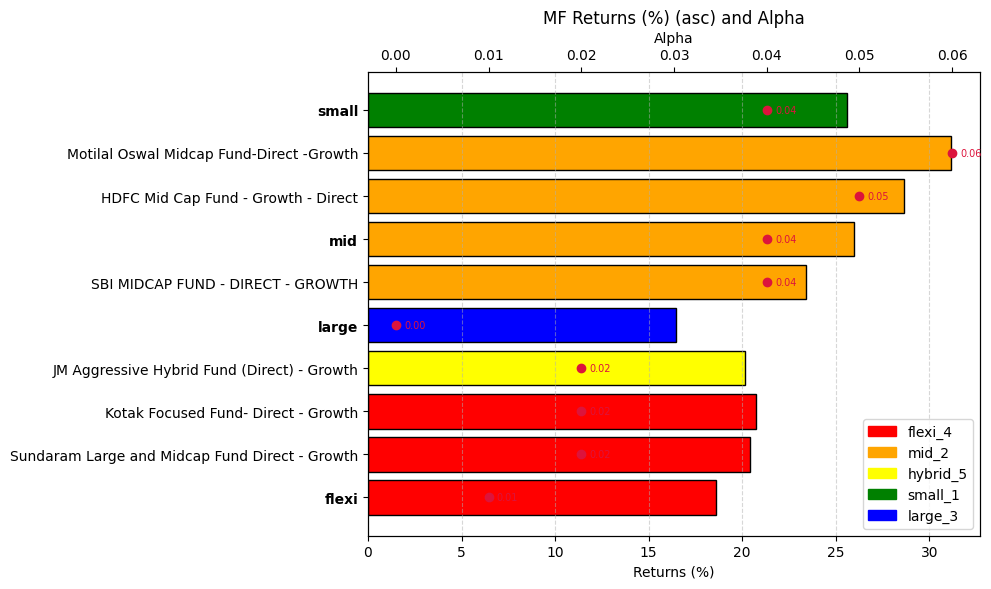

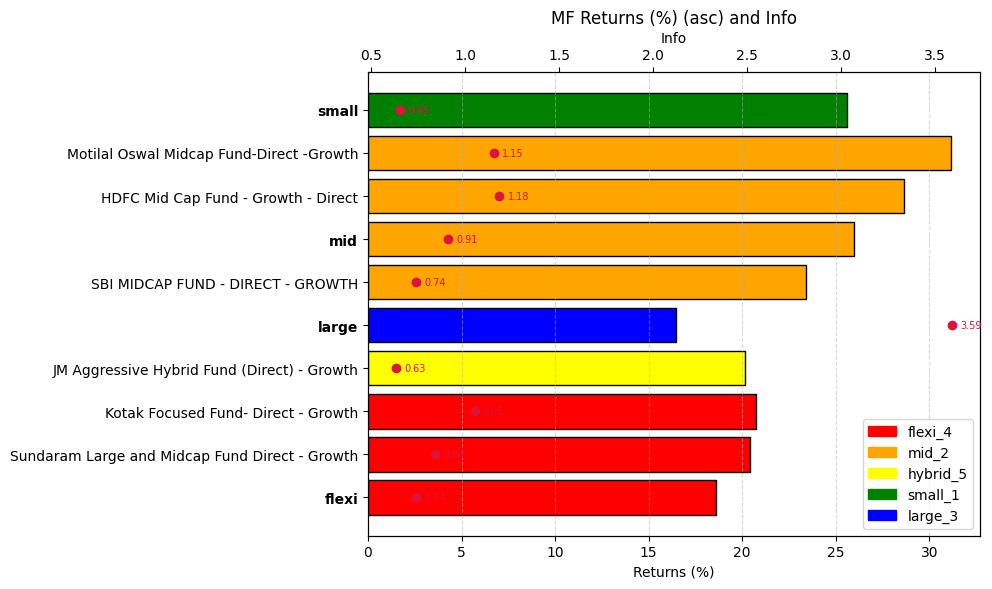

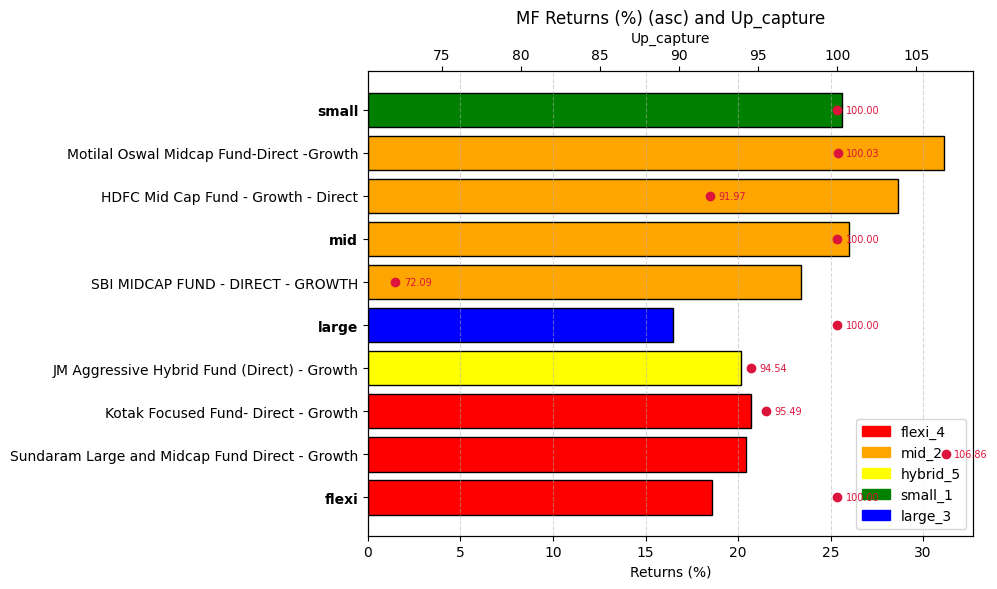

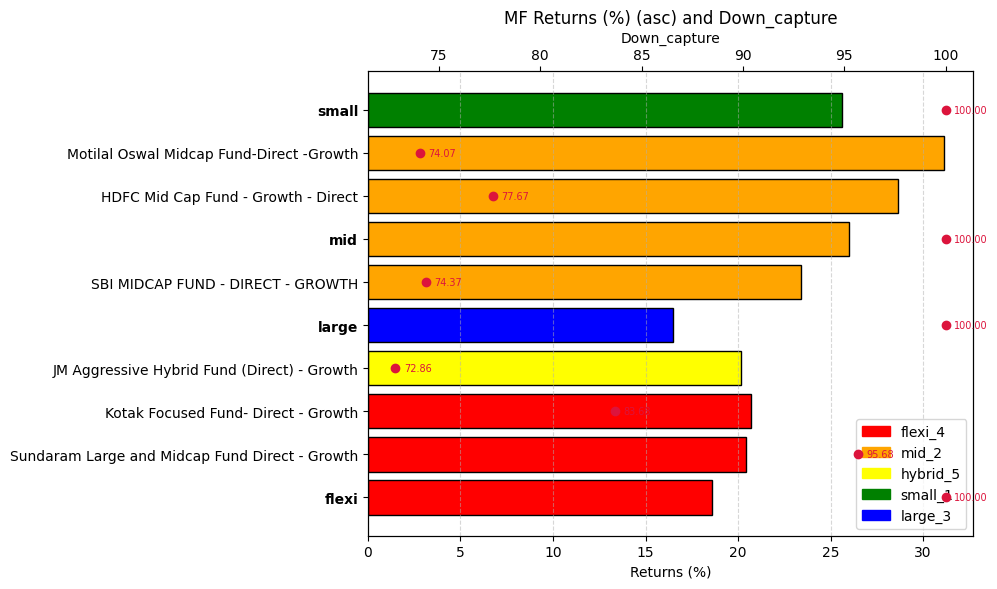

In [10]:
## 3.1 Returns vs Ratios for MFs
#     - Plot returns (ascending) vs each ratio (beta, alpha, sharpe, info)

import matplotlib.patches as mpatches

rainbow_colors = ['Red', 'Orange', 'Yellow', 'Green', 'Blue', 'Indigo', 'Violet']
col_map = {cat:color for cat, color in zip(mf_df['id'].unique(), rainbow_colors)}


for ratio in ratios.keys():
    # prepare dataframe for plotting
    df_plot = mf_df[['id','name', 'returns_%', ratio]].copy()
    df_plot = df_plot.dropna(subset=['returns_%', ratio]).sort_values(['id','returns_%'], ascending=[True,True]).reset_index(drop=True)
    colors = df_plot['id'].map(col_map).to_list()

    names = df_plot['name'].tolist()
    y = np.arange(len(names))

    fig, ax = plt.subplots(figsize=(10, max(6, len(names) * 0.18)))
    ax.barh(y, df_plot['returns_%'], color=colors, edgecolor='k')
    ax.set_yticks(y)
    ax.set_yticklabels(names)
    ax.set_xlabel('Returns (%)')
    ax.set_title(f'MF Returns (%) (asc) and {ratio.capitalize()}')

    # secondary axis for the ratio
    ax2 = ax.twiny()
    ax2.plot(df_plot[ratio].values, y, 'o', color='crimson')
    ax2.set_xlabel(ratio.capitalize())

    # annotate ratio values and bold portfolio funds
    my_names_set = set(list(my_mf_names)) if 'my_mf_names' in globals() else set()
    for i, (val, lab) in enumerate(zip(df_plot[ratio].values, ax.get_yticklabels())):
        try:
            ax2.annotate(f'{val:.2f}', xy=(val, i), xytext=(6, 0), textcoords='offset points',
                         va='center', fontsize=7, color='crimson')
        except Exception:
            # fallback for non-scalar values
            ax2.annotate(f'{float(np.asarray(val).flat[0]):.2f}', xy=(float(np.asarray(val).flat[0]), i),
                         xytext=(6, 0), textcoords='offset points', va='center', fontsize=7, color='crimson')

        if lab.get_text() in my_names_set:
            lab.set_fontweight('bold')

    ax.grid(True, axis='x', which='major', linestyle='--', alpha=0.5)

    # 4. Create manual patches for the custom legend
    patches = [mpatches.Patch(color=c, label=l) for l,c in col_map.items()]
    ax.legend(handles=patches, loc='lower right')
    
    # Bold benchmarks
    for i, label in enumerate(ax.get_yticklabels()):
        if label.get_text() in benchmark_idx['name']:
            label.set_fontweight('bold')
            label.set_color('black')


    plt.tight_layout()
    plt.show()

### 4. Rolling ratio variations

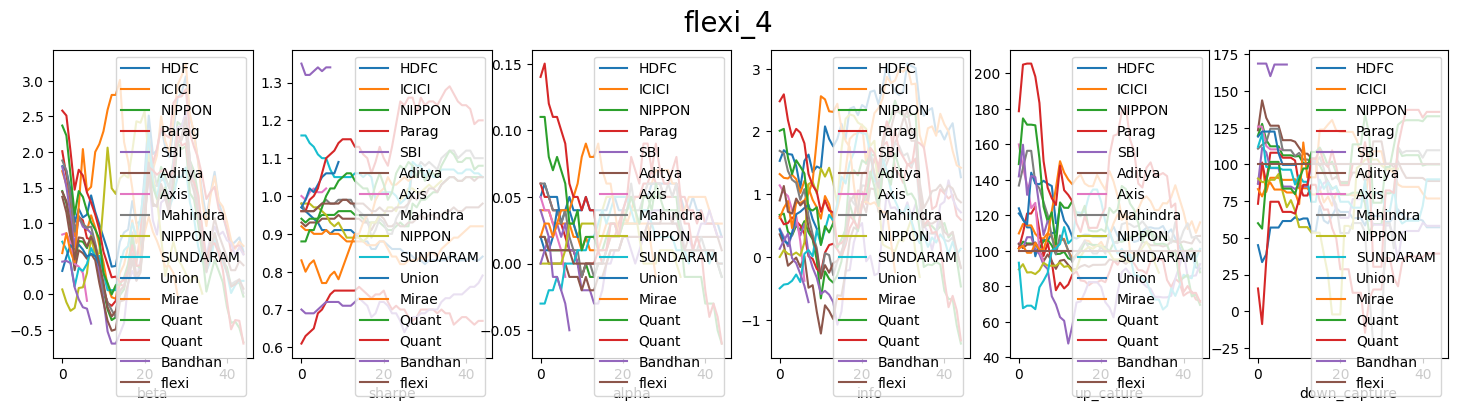

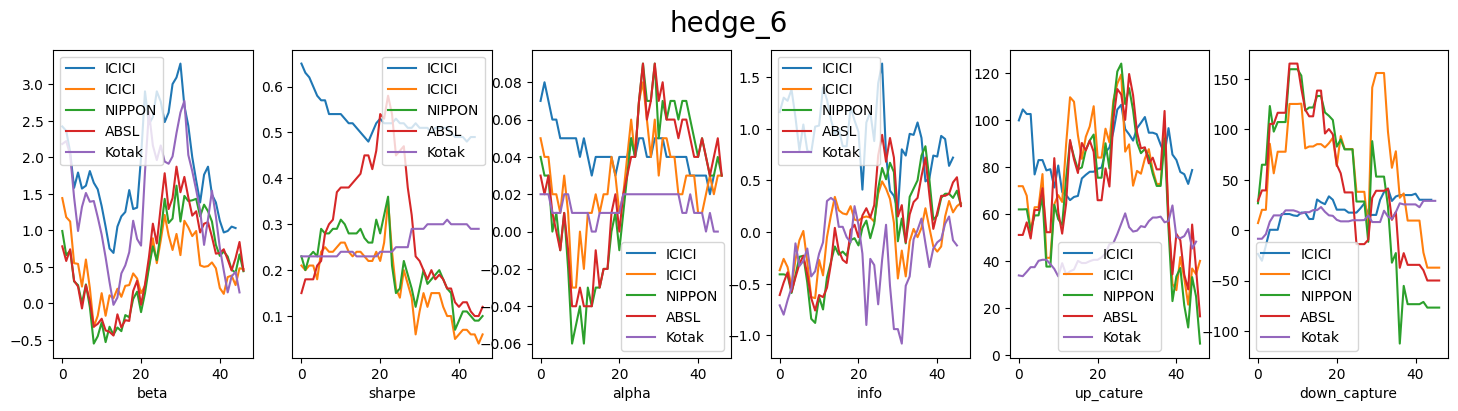

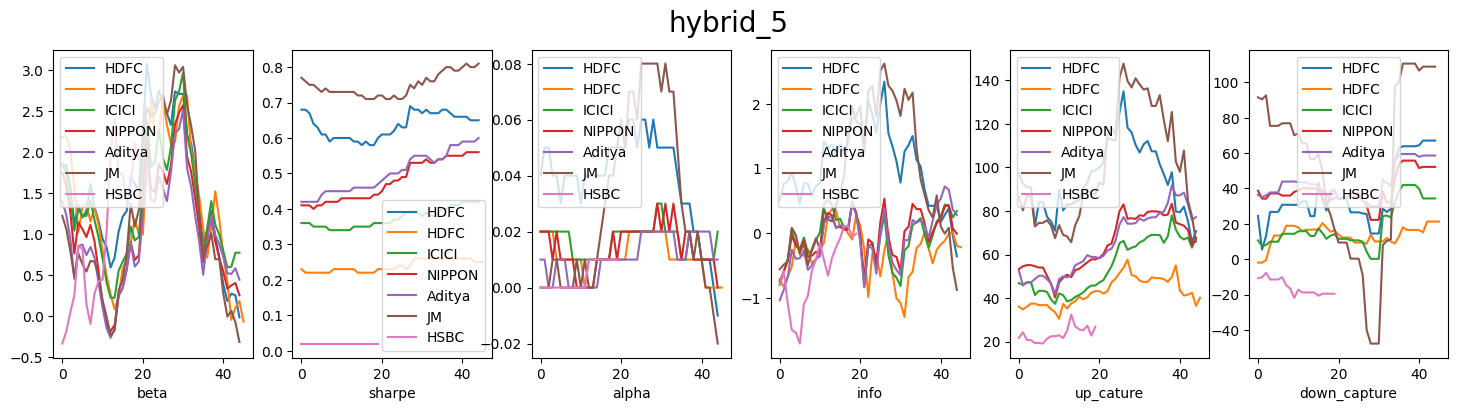

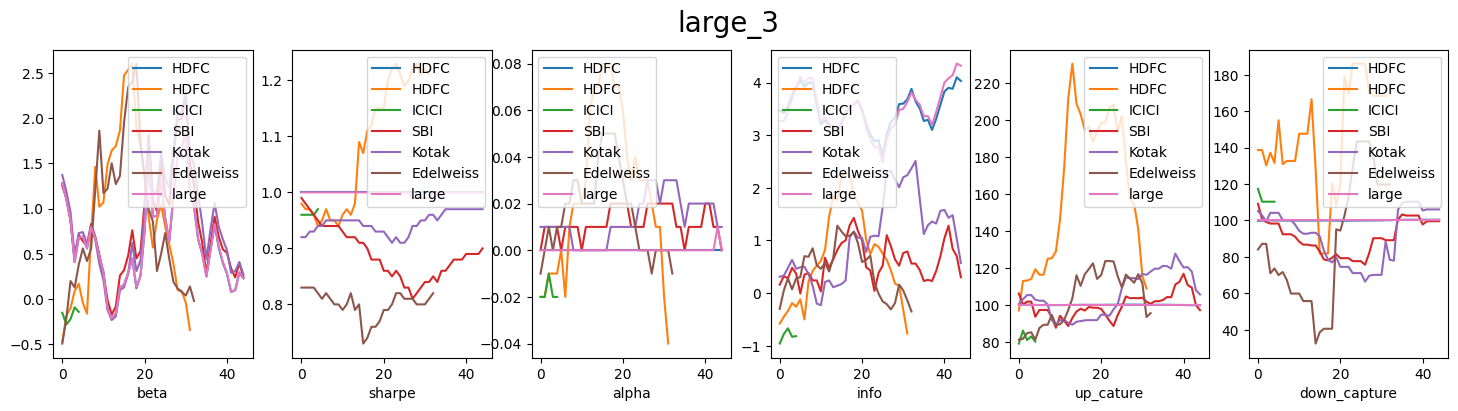

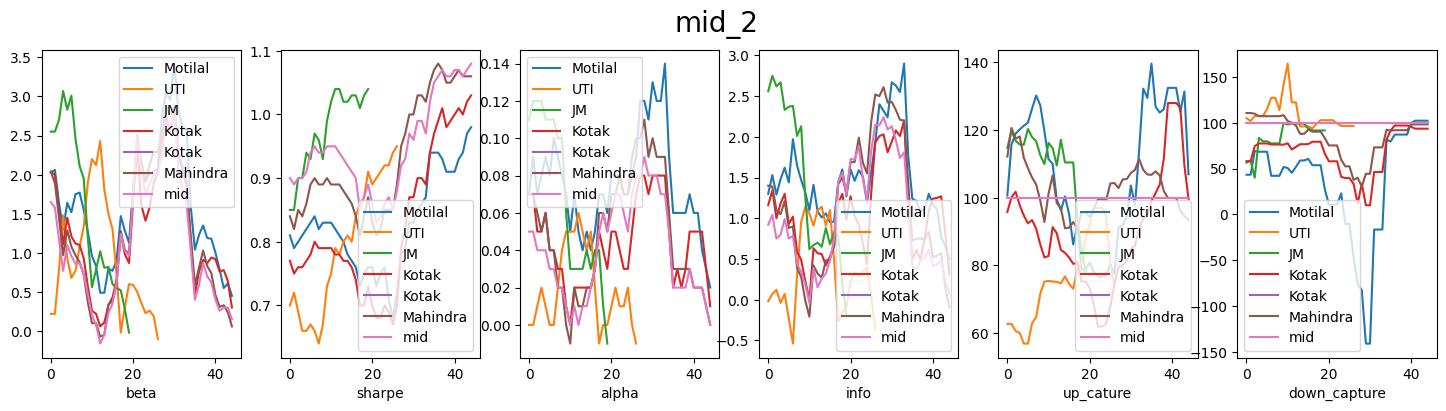

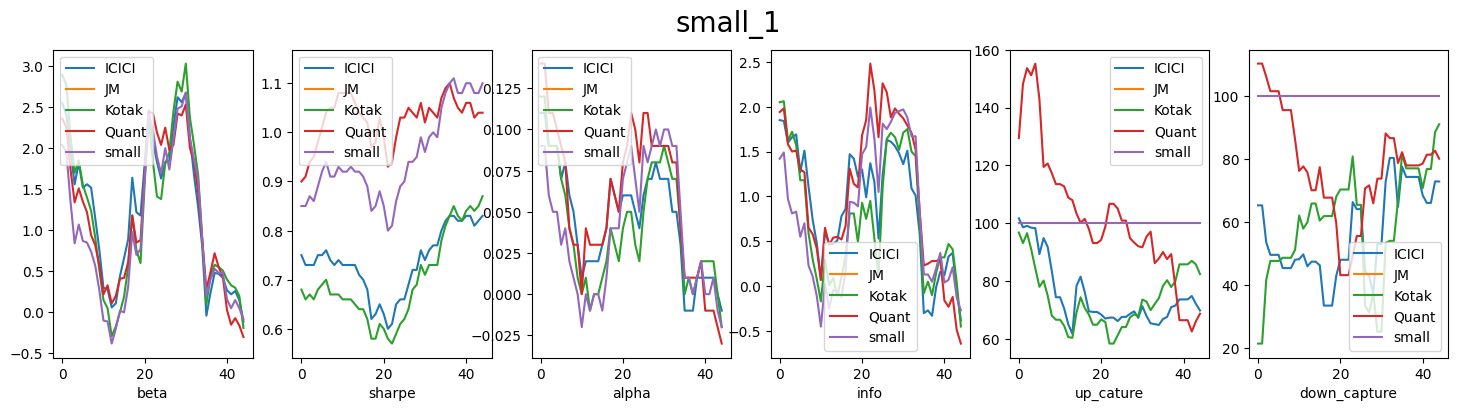

In [216]:
for cat, df in mf_df.groupby('id'):
    fig = plt.figure(figsize=(18,4))
    fig.suptitle(cat, fontsize=20)
    
    for i, ratio in enumerate(ratio_names):

        ax = fig.add_subplot(1,len(ratio_names),i+1)
        for index, row in df.iterrows():
            plt.plot(row[f'rolling_{ratio}'], label='_'.join(row['name'].split(' ')[:1]))
        plt.xlabel(ratio)
        plt.legend()



    plt.show()

### 5. Plotting all ratios together for each fund and sorted
- Can be useful for comparison within each other

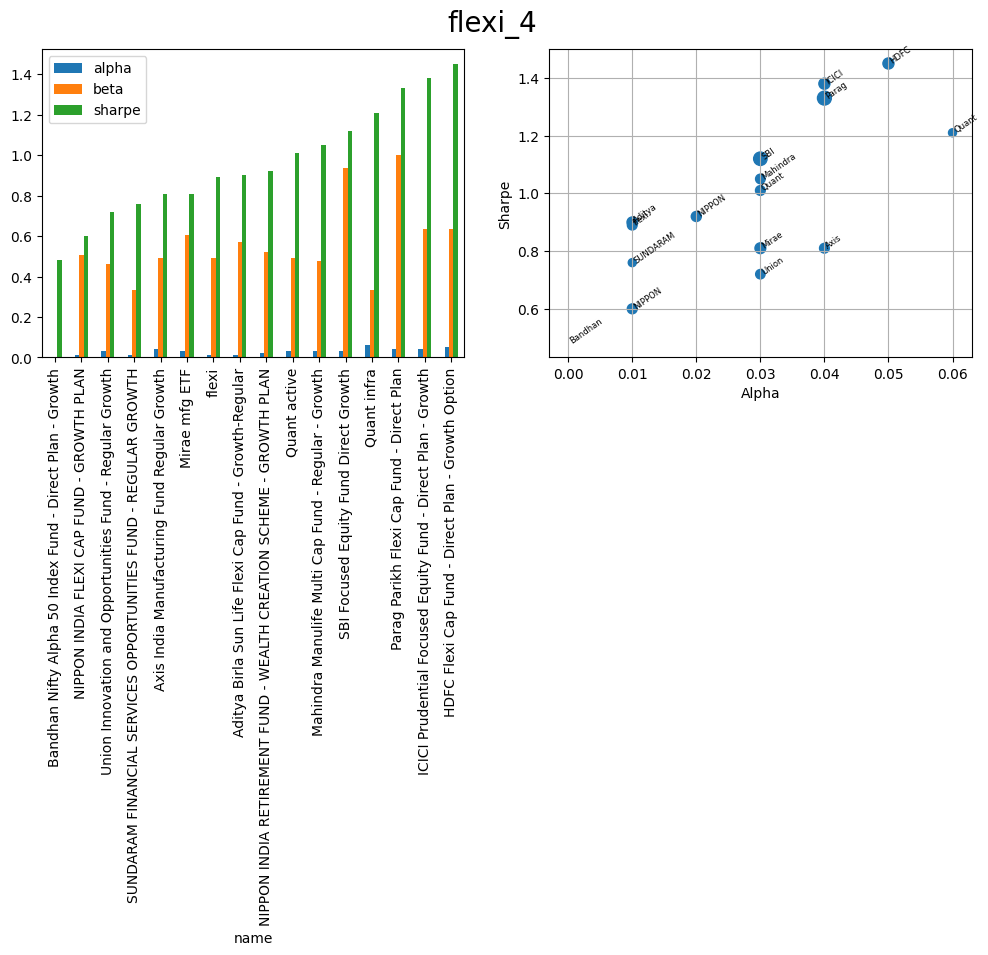

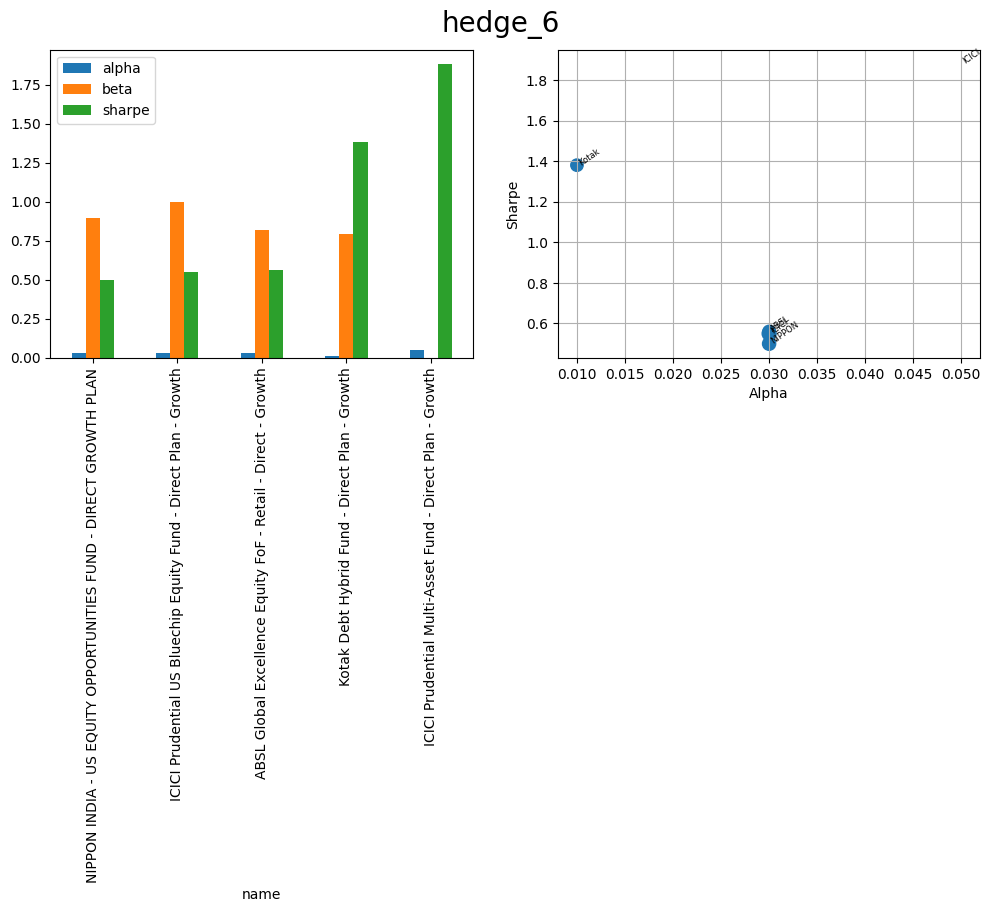

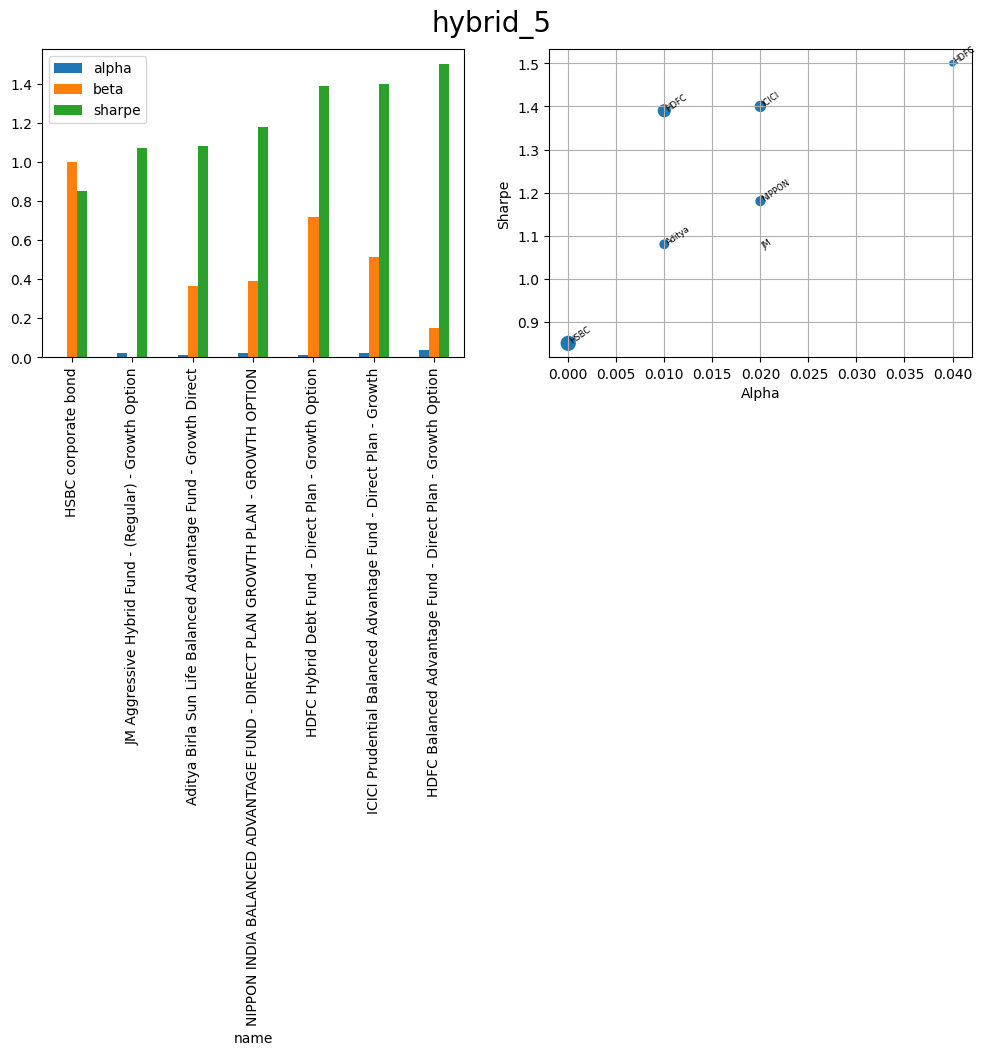

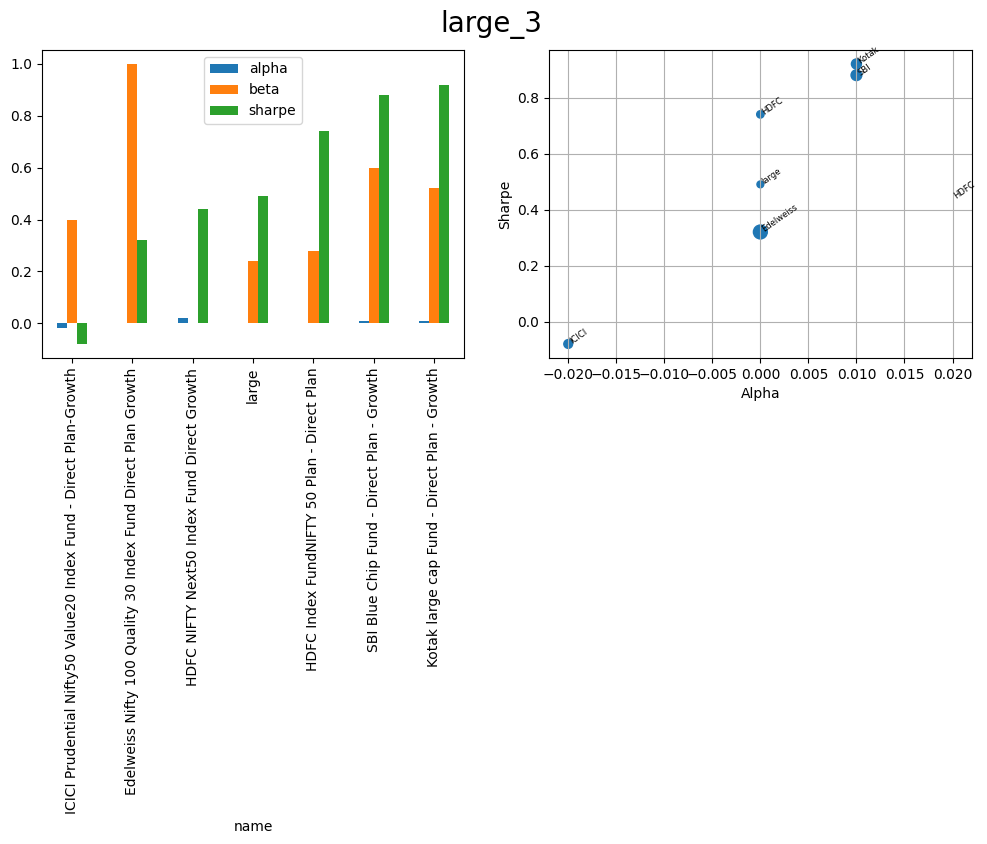

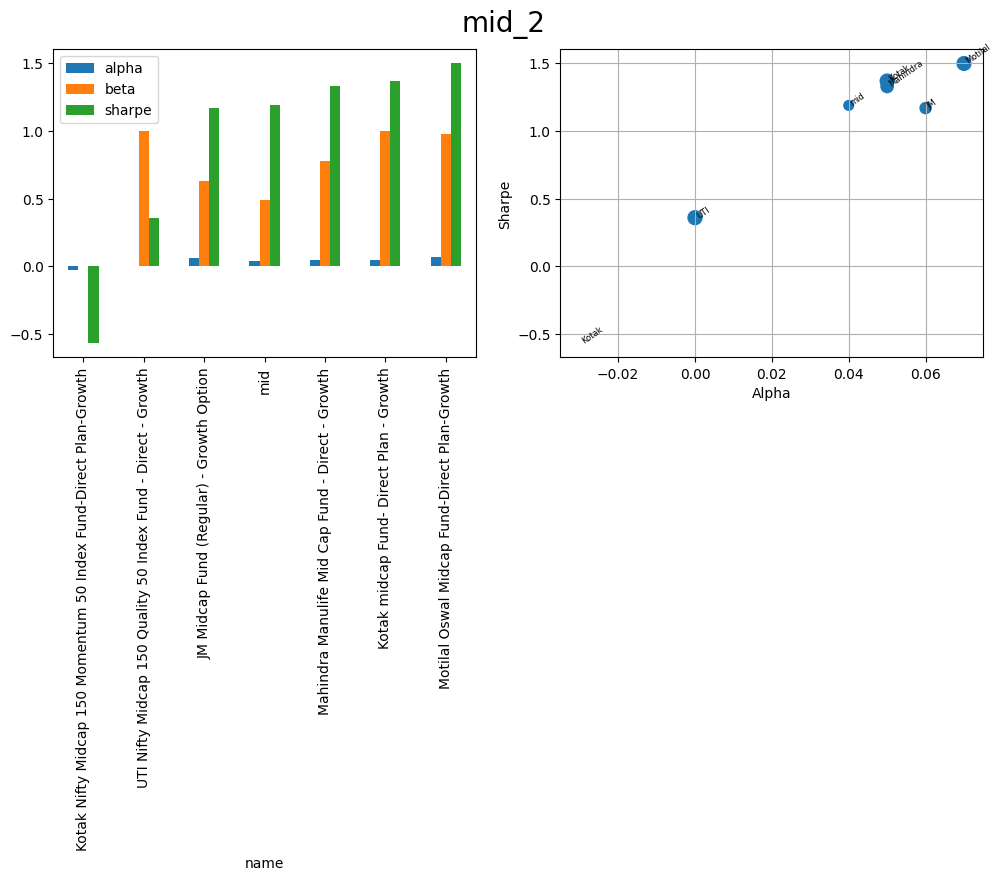

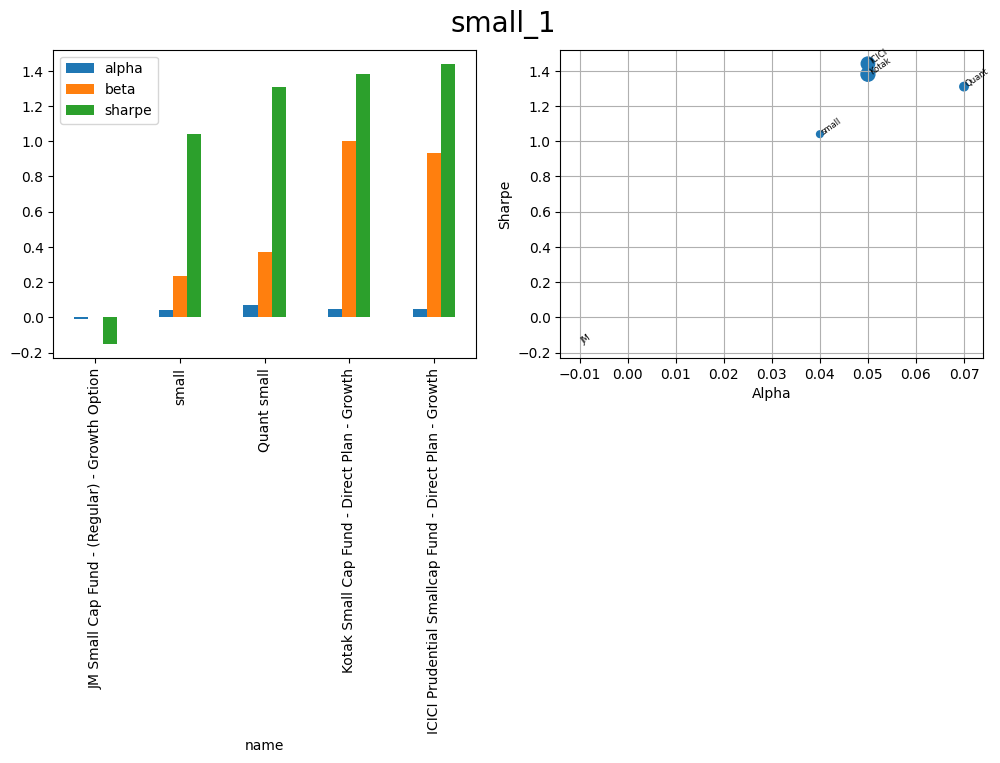

In [19]:
for cat, df in mf_df.groupby('id'):
    fig = plt.figure(figsize=(12,4))
    fig.suptitle(cat, fontsize=20)
    ax = fig.add_subplot(1,2,1)
    df = df[['name','alpha', 'beta', 'sharpe']].copy()
    df['beta'] = 1 - (df['beta'] - df['beta'].min()) / (df['beta'].max() - df['beta'].min())
    df.sort_values(by='sharpe').set_index('name').plot.bar(ax=ax)

    ax = fig.add_subplot(1,2,2)
    plt.scatter(df['alpha'], df['sharpe'], s=df['beta']*100)
    for _, row in df.iterrows():
        plt.annotate(row['name'].split(' ')[0], xy=(row['alpha'],row['sharpe']), fontsize=6, rotation=35)
    plt.xlabel('Alpha')
    plt.ylabel('Sharpe')
    plt.grid(True, which='both')
    plt.show()


## Part 2: Portfolio Analysis

- Below is the example portfolio for ₹20 lakhs
    - 60% in equity (mid, small, flexi), 10% US funds, 15% large, 15% hybrid funds
- Change them as per your funds
- This code is with yfinance, MF codes can be obtained from yahoo finance

In [30]:
mf_names = ['Quant active fund direct growth', 'Kotak Small cap', 'Parag Parikh Flexi Cap Fund', 'MM mid cap unnati yojna', 'Kotak Emerging Equity', 'MAKEINDIA', 'Quant Infrastructure',
            'Nippon india - US equity oppo', 'ICICI Pru US Bluechip', 'HDFC Index Fund Nifty 50', 'HDFC NIFTY Next 50 Index Fund', 'Canera robeco bluechip', 'Absl balance advantage', 'HDFC debt hybrid']
mf_codes = ['0P0000XW4E.BO', '0P0000XV6I.BO', '0P0000YWL1.BO', '0P0001CEW2.BO', '0P0000XV5R.BO', 'MAKEINDIA.NS', '0P0000XW4O.BO', '0P00016GW1.BO', '0P0000XUZC.BO', '0P0000XW7T.BO', '0P0001NK4B.BO',
            '0P0000XW0O.BO', '0P0000XV24.BO', '0P0000XW8G.BO']
units = [276.59, 1402.33, 4028.26, 15593.96, 1392.83, 900.00, 3069.79, 3612.31, 2329.89, 617.98, 12461.10, 3373.96, 1890.72, 2405.14]
costs = [120000, 250000, 205000, 280000, 120000, 75000, 75000, 90000, 110000, 100000, 120000, 150000, 150000, 150000]

mf_mapping = {code:name for code, name in zip(mf_codes, mf_names)}

period1 = '1y'

mf_nav = {}
max_len = 0
latest = []


for code in mf_codes:
    stock = yf.Ticker(code)
    hist = stock.history(period=period1)
    mf_nav[code] = hist['Close'].values
    latest.append(hist.index.values[-1])
    if len(hist) > max_len:
        max_len = len(hist)
        dates = hist.index.values

current_val = [vals[-1]*x for vals, x in zip(mf_nav.values(), units)]
current_nav = [vals[-1] for vals in mf_nav.values()]
print('\nCurrent Value = ', round(sum(current_val)), '\n')



## Not Accurate, rough estimate of CAGR from given date
years = (pd.to_datetime('today') - pd.to_datetime('12 Aug 2022')).total_seconds() / (24 * 60 * 60) / 365
cagr = (sum(current_val) / 2000000) ** (1 / years) - 1
print(f"The CAGR is {cagr:.2%}")




Current Value =  3476277 

The CAGR is 18.43%


In [29]:
## Summary

mf_df = pd.DataFrame({'mf_names': mf_names, 'mf_codes': mf_codes, 'units':units, 'costs':costs,
                      'NAV':current_nav, 'value':current_val,
                      'date':latest,
                      })
mf_df['profit'] = mf_df['value'] - mf_df['costs']
mf_df.round(2)

,mf_names,mf_codes,units,costs,NAV,value,date,profit
0,Quant active fund direct growth,0P0000XW4E.BO,276.59,120000,681.68,188545.26,2025-11-09 18:30:00,68545.26
1,Kotak Small cap,0P0000XV6I.BO,1402.33,250000,302.36,424015.50,2025-11-09 18:30:00,174015.50
2,Parag Parikh Flexi Cap Fund,0P0000YWL1.BO,4028.26,205000,93.54,376814.72,2025-11-06 18:30:00,171814.72
3,MM mid cap unnati yojna,0P0001CEW2.BO,15593.96,280000,38.33,597674.40,2025-11-09 18:30:00,317674.40
4,Kotak Emerging Equity,0P0000XV5R.BO,1392.83,120000,159.83,222610.45,2025-11-09 18:30:00,102610.45
5,MAKEINDIA,MAKEINDIA.NS,900.00,75000,155.46,139914.01,2025-11-10 18:30:00,64914.01
6,Quant Infrastructure,0P0000XW4O.BO,3069.79,75000,42.08,129162.95,2025-11-09 18:30:00,54162.95
7,Nippon india - US equity oppo,0P00016GW1.BO,3612.31,90000,40.88,147663.64,2025-11-06 18:30:00,57663.64
8,ICICI Pru US Bluechip,0P0000XUZC.BO,2329.89,110000,76.12,177351.23,2025-11-06 23:00:00,67351.23
9,HDFC Index Fund Nifty 50,0P0000XW7T.BO,617.98,100000,248.57,153610.98,2025-11-09 18:30:00,53610.98


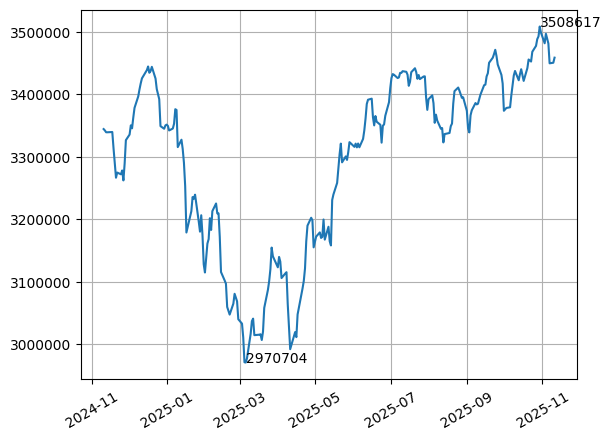

In [30]:
## Variation of Portfolio over given period with Min and Max values

total = np.zeros(max_len,)

fig, ax = plt.subplots()
for i, vals in enumerate(mf_nav.values()):
    prices = np.concatenate([[vals[0]]*(max_len-len(vals)), vals])*units[i]
    # ax.plot(prices, label=mf_names[i])
    total += prices

ax.plot(dates, total, label='Total')
ax.ticklabel_format(useOffset=False, style='plain', axis='y')

max_val, max_idx = np.max(total), np.argmax(total)
min_val, min_idx = np.min(total), np.argmin(total)
ax.annotate(f'{round(max_val)}', xy=(dates[max_idx], max_val))
ax.annotate(f'{round(min_val)}', xy=(dates[min_idx], min_val))
plt.grid(True, which='both')
plt.xticks(rotation=30)
plt.show()

In [31]:
## Current month's return


daily_df = pd.DataFrame({'date':dates, 'value':total})
daily_df['month'] = daily_df['date'].dt.month
daily_df['change'] = daily_df['month'] - daily_df['month'].shift(-1)

idx = daily_df['change'].where(daily_df['change']!=0).dropna().index[-1]

change = (total[-1] - total[idx])/total[idx]
print('Change : ', round(change*100, 2))

daily_df.iloc[idx:, :2].round()

Change :  -1.15


,date,value
241,2025-10-30 18:30:00,3498908.0
242,2025-11-02 18:30:00,3481794.0
243,2025-11-03 18:30:00,3497070.0
244,2025-11-05 18:30:00,3481581.0
245,2025-11-06 18:30:00,3449740.0
246,2025-11-09 18:30:00,3450682.0
247,2025-11-10 18:30:00,3458795.0
